**Fecha de creación**: 08/06/2026

**Lenguaje de programación**: Python 3.12.13

**Descripción del programa**:
Se aplica la técnica de regresión logística de acuerdo al artículo de "Introduction to Logistic Regression" por Moo K. Chung. Se utilizó el conjunto de datos descargado [UC Irvine Machine Learning Repository](https://https://archive.ics.uci.edu/dataset/426/autism+screening+adult), correspondientes a respuestas de Adultos que contestaron el instrumento de evaluación Q10 (Cociente de Espectro Autista). El instrumento traducido al español puede revisarse en [autism research centre](https://www.autismresearchcentre.com/content/uploads/2024/11/AQ10-Adult_Spanish.pdf). Se ajustan tres modelos con 11, 5 y 2 grados de libertad, encontrándose el modelo de 5 grados de libertad como el más útil.

In [1]:
#@title Librerías
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,roc_curve,confusion_matrix
from scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#@title Leer datos y explorar data frame
df = arff.loadarff('/content/Autism-Adult-Data.arff')
df = pd.DataFrame(df[0])
print(*list(df.columns), sep='\n')
#Dar formato a los datos
df = df.map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
#Descartar columnas que no son de interés
df=df.drop(columns=['age','gender','ethnicity','jundice','contry_of_res','used_app_before','age_desc','relation','Class/ASD'])
df.rename(columns={'austim': 'autismo'}, inplace=True) #Se renombra para evitar typos
df['autismo']=df['autismo'].map({'yes': 1, 'no': 0}) #Se pasan a 1 y 0 los 'yes'/'no'
#Impresión de aspectos relevantes del data frame
print(f'\nSujetos con {df.autismo.value_counts().to_string()}\n') #Conteo de sujetos con y sin diagnóstico de TEA
print(f'Datos faltantes\n{df.isnull().sum()}') #Verificar que no hay columnas con datos faltantes
print(f'\nEstadísticos descriptivos\n{df.describe().round(3)}') #Impresión de estadísticos descriptivo con redondeo a 3 cifras

A1_Score
A2_Score
A3_Score
A4_Score
A5_Score
A6_Score
A7_Score
A8_Score
A9_Score
A10_Score
age
gender
ethnicity
jundice
austim
contry_of_res
used_app_before
result
age_desc
relation
Class/ASD

Sujetos con autismo
0    613
1     91

Datos faltantes
A1_Score     0
A2_Score     0
A3_Score     0
A4_Score     0
A5_Score     0
A6_Score     0
A7_Score     0
A8_Score     0
A9_Score     0
A10_Score    0
autismo      0
result       0
dtype: int64

Estadísticos descriptivos
       autismo   result
count  704.000  704.000
mean     0.129    4.875
std      0.336    2.501
min      0.000    0.000
25%      0.000    3.000
50%      0.000    4.000
75%      0.000    7.000
max      1.000   10.000


# Funciones

In [3]:
#@title Separación de datos para posterior validación simple
def separacion(vindep,vdep,tamEntrenamiento,semilla):
    X_train, X_test, y_train, y_test = train_test_split(
    vindep.values,
    vdep.values,
    train_size   = tamEntrenamiento,
    random_state = semilla, #Semilla para reproducibilidad
    shuffle      = True,
    stratify     = vdep) #Clasificación proporcional
    return X_train, X_test, y_train, y_test

## Modelo

In [4]:
#Regresion Logística adaptando el código de matlab del artículo de Chung (2020)
def RL(X, y,tabla=False):
    X=X.astype(float)
    y=y.astype(float).reshape(-1,1)
    n, *resto = X.shape
    if resto==[]:
      k=1
    else:
      k=resto[0]
    # Se añade una columna de unos para el intersección
    X = np.hstack([np.ones((n, 1)), X])

    # Beta se inicializa en ceros con el tamaño de la cantidad de columnas de X +1
    beta = np.zeros((k + 1, 1))
    gnorm = 1

    #Estimación de coeficientes beta
    while gnorm > 0.001:
        # Cálculo de probabilidades, el @ es para multiplicar matrices
        extb = np.exp(X @ beta)
        pi = extb / (1 + extb)

        # Gradiente: dirección de máximo crecimiento
        g = X.T @ (y - pi)
        gnorm = np.linalg.norm(g)

        s_diag = (pi * (1 - pi)).ravel()
        S = np.diag(s_diag) # Matriz de pesos para el Hessiano

        H = X.T @ S @ X # Hessiano: matriz de segundas derivadas

        beta = beta + np.linalg.pinv(H) @ g # Actualización de Newton-Raphson

    # Cálculo de log-likelihood ratio test entre el modelo propuesto y la hipótesis nula
    ll = log_likelihood(X, y, beta)
    ll_nulo = modelo_nulo(X,y)
    LR       = L_Ratio(ll_nulo,ll)
    #p-value usando scipy.stats
    p_valor  = chi2.sf(LR, df=k)   # sf = 1 - cdf (cola derecha)

    #Impresión de resultados con formato
    if tabla==True:
        sig      = "p_valor < 0.001" if p_valor < 0.001 else "p_valor < 0.01" if p_valor < 0.01 else "p_valor < 0.05" if p_valor < 0.05 else "p_valor < 0.1"  if p_valor < 0.1  else ""
        print("  Datos del modelo\n")
        print(f"  {'GL':<3}{'Ll_Ratio':>11} {'p-valor':>9}  {'Sig.':>19}")
        print("  " + "-" * 65)
        print(f"  {k+1:<2}{LR:>10.3f}{p_valor:>26}  {sig:>16}")

    # Regresa los valores de los coeficientes, log-likelihood del modelo, log-likelihood ratio y el p-value respecto a la hipótesis nula
    return beta, ll,LR, p_valor

In [5]:
#Estimación de log-likelihood del modelo nulo
def modelo_nulo(X,y):
    n = X.shape[0]
    # Solo intercepto
    X_nulo        = np.ones((n, 1))   # sin hstack, porque ya eS el intercepto
    beta_nulo     = np.zeros((1, 1))
    gnorm         = 1
    while gnorm > 0.001:
        xb        = X_nulo @ beta_nulo
        pi        = np.exp(xb) / (1 + np.exp(xb))
        g         = X_nulo.T @ (y - pi)
        gnorm     = np.linalg.norm(g)
        s_diag    = (pi * (1 - pi)).ravel()
        H         = X_nulo.T @ (s_diag[:, None] * X_nulo)
        beta_nulo = beta_nulo + np.linalg.pinv(H) @ g

    ll_nulo = log_likelihood(X_nulo, y, beta_nulo)
    return ll_nulo

In [6]:
#Logaritmo de verosimilitud con clip en pi para evitar indefiniciones
def log_likelihood(X, y, beta):
    xb  = X @ beta
    pi  = np.exp(xb) / (1 + np.exp(xb))
    # Clip para evitar log(0)
    pi = np.clip(pi, 1e-30, 1 - 1e-30)
    ll = np.sum(y * xb + np.log(1 - pi))
    return ll

In [7]:
#Log-likelihood ratio test
def L_Ratio(ll_reducido,ll_completo):
  return 2*(ll_completo-ll_reducido)

## Evaluación

In [8]:
#@title Cálculo de la probabilidad pi y la clasificación (pi binarizada) del modelo de acuerdo a un umbral
def predecir(X,beta,y=None,umbral=None,graf=None):
  X=X.astype(float)
  if hasattr(X, "values"):
      X = X.values
  n, *resto = X.shape
  if resto==[]:
    X = X.reshape(-1, 1)
  X=np.hstack([np.ones((n, 1)), X]) #Se añade la intersección
  Z = X @ beta
  extb = np.exp(Z)
  pi = extb / (1 + extb) #distirbución de probabilidad
  pi = np.clip(pi, 1e-30, 1 - 1e-30)
  if umbral:
    predicciones=np.where(pi<umbral, 0, 1) #Predicciones al binarizar pi
    if graf=='logodds':
      Z,pi =zip(*sorted(zip(Z,pi)))
      pi,Z = np.array(pi), np.array(Z)
      return pi.flatten(),Z.flatten() #Devuelve pi y log odds para graficar
    if graf=='univar':
      pi,predicciones =zip(*sorted(zip(pi,predicciones)))
      pi,predicciones = np.array(pi), np.array(predicciones)
      x=range(len(pi))
      return pi.flatten(),predicciones.flatten(),x #Devuelve pi, las predicciones binarizadas y x para graficar
    else:
      return pi.flatten(),predicciones.flatten() #Devuelve pi y la clasificacion

  #Cálculo del umbral usando el estadístico de Youden
  else:
    if hasattr(y, "values"):
      y = y.values
    y = y.reshape(-1, 1)
    fpr, tpr, umbrales = roc_curve(y, pi)
    j_statistic = tpr - fpr
    optimal_idx = np.argmax(j_statistic)
    optimal_threshold = umbrales[optimal_idx]
    print(f"  Umbral óptimo: {optimal_threshold:.4f}")
    return optimal_threshold.flatten()

In [9]:
#@title Cálculo de métricas de discriminación
def validacion(X,beta,y_test,umbral_ajustado,matriz=False):
  _,preds=predecir(X,beta,umbral=umbral_ajustado)
  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
  #Se calculan las predicciones
  sensibilidad=tp/(tp+fn)
  especificidad=tn/(tn+fp)
  precision = tp/(tp+fp)
  roc = roc_auc_score(y_test, preds)

  #Impresión de encabezado con formato
  print("  Datos de validación y discriminación\n")
  print(f"{'Precisión':>11}{'Area roc':>9}{'Especificidad':>15}{'Sensibilidad':>16}")
  print("  " + "-" * 65)
  #Impresión de resultados
  print(f"{precision:>8.4f}{roc:>10.4f}{especificidad:>10.4}{sensibilidad:>17.4}\n")

  if matriz==True:
    print("\n  Matriz de Confusión")
    print("  " + "-" * 32)
    print(f"  {'':<12} {'Pred 0':>8} {'Pred 1':>8}")
    print(f"  {'Real 0':<12} {tn:>8} {fp:>8}")
    print(f"  {'Real 1':<12} {fn:>8} {tp:>8}")

In [10]:
#@title Estimación de la contribución de cada variable independiente
def lrt_vars(X, y,beta,ll,nombres_vars=None):
    #Formateo de datos para evitar errores en el proceso
    ll=float(ll)
    if hasattr(X, "values"):
      X = X.values
    if hasattr(y, "values"):
      y = y.values
    n, *resto = X.shape
    X = np.hstack([np.ones((n, 1)), X])
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    if resto==[]:
      k=2
      X = X.reshape(-1, 1)
    else:
      k=resto[0]+1

    #Inicializar arreglo de resultados
    resultados = []

    #Encabezado de los datos
    print(f"  Likelihood Ratio por variables\n")
    print(f"  {'Variable':<12}{'Coef':>7}{'LR stat':>10}{'p-valor':>12}  {'Sig':>2}    OR")
    print("  " + "-" * 60)
    nombres_vars= pd.Index(['Intersec']+nombres_vars.tolist())

    for j in range(k):
        # Modelo sin la variable j
        X_reducido      = np.delete(X, j, axis=1)   # elimina columna j
        if X_reducido.shape[1] == 0:
            X_reducido = np.ones((n, 1))  # Columna de unos para el modelo reducido
        _,lred,_,_ = RL(X_reducido, y)
        lred=float(lred)
        LR_j=L_Ratio(lred,ll)
        p_j      = chi2.sf(LR_j, df=1)
        sig      = "***" if p_j < 0.001 else "**" if p_j < 0.01 else "*" if p_j < 0.05 else "."  if p_j < 0.1  else "!" if p_j>=0.1 else ""
        OR=np.exp(beta[j])[0]

        # Se imprimen los nombres de las variables independientes, y sus valores calculados
        print(f"  {nombres_vars[j]:<12}{beta[j].item():>8.4f}{LR_j:>10.4f} {p_j:>10.4f}  {sig:>2}    {OR:<2.4}")
        #resultados.append((nombres_vars[j], LR_j, p_j))

    #Leyenda de la comparación visual de la significancia estadística
    print("\n  *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ! p>=0.1")

In [11]:
#@title LLRT entre modelos (Comparación entre modelos reducidos y completos)
def comparar(LLS,LLC,betaS,betaC,nombres):
  LRmods=L_Ratio(LLS,LLC) #Likelihood-ratio test
  p_value = chi2.sf(LRmods, df=len(betaC)-len(betaS)) #Cálculo del p-value con los grados de liebrtad
  sig      = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "."  if p_value < 0.1  else "!" if p_value>=0.1 else ""
  #Impresión de encabezado
  print('  Comparación '+nombres)
  print("  " + "-" * 55)
  #Impresión de valores
  print(f'  LLRT: {LRmods:.6f}    p-value:{p_value:.6f}     sig.{sig}')
  print('\n')

## Función de control

In [12]:
def modelar(X,Y,porcion,semilla,gl,tablav=True,entrenamiento=False):
  X_train,X_test, y_train,y_test=separacion(X,Y,porcion,semilla)
  #Formateo de los datos para evitar errores
  if gl==2:
    nombres= X.to_frame().columns
    X_train=X_train.reshape(-1,1)
    X_test=X_test.reshape(-1,1)
  else:
    nombres=X.columns
  beta,LL,LR,pval=RL(X_train,y_train,tabla=tablav)
  print('\n')
  umbral=predecir(X_train,beta,y_train) #Umbral óptimo usando la curva roc
  print('\n')
  validacion(X_test,beta,y_test,umbral,matriz=True) #Impresión de métricas
  print('\n\n')
  lrt_vars(X_train,y_train,beta,LL,nombres) #Evaluación de la contribución de cada variable predictora
  if entrenamiento==True:
    return X_train,X_test,y_train,y_test,umbral,beta,LL
  else:
    return X_test,y_test,umbral,beta,LL

# Data Set: Cuestionario Q10

## Modelos

In [13]:
#@title Modelo con 11 gl
X_test11,y_test11,umbral11,beta11,LL11=modelar(df.drop(columns=['autismo','result']),df['autismo'],0.8,123,11,tablav=True)

  Datos del modelo

  GL    Ll_Ratio   p-valor                 Sig.
  -----------------------------------------------------------------
  11    30.983     0.0005904305308750772   p_valor < 0.001


  Umbral óptimo: 0.1079


  Datos de validación y discriminación

  Precisión Area roc  Especificidad    Sensibilidad
  -----------------------------------------------------------------
  0.2105    0.7005    0.5122           0.8889


  Matriz de Confusión
  --------------------------------
                 Pred 0   Pred 1
  Real 0             63       60
  Real 1              2       16



  Likelihood Ratio por variables

  Variable       Coef   LR stat     p-valor  Sig    OR
  ------------------------------------------------------------
  Intersec     -3.0219    0.0000     1.0000   !    0.04871
  A1_Score      0.5327    2.8025     0.0941   .    1.703
  A2_Score      0.0060    0.0005     0.9822   !    1.006
  A3_Score      0.0072    0.0006     0.9805   !    1.007
  A4_Score      0.8218    7.

In [14]:
# @title Modelo con 5 gl
X_test5,y_test5,umbral5,beta5,LL5=modelar(df[['A1_Score','A4_Score','A7_Score','A10_Score']],df['autismo'],0.8,123,5,tablav=True)

  Datos del modelo

  GL    Ll_Ratio   p-valor                 Sig.
  -----------------------------------------------------------------
  5     28.239    1.1156613885595572e-05   p_valor < 0.001


  Umbral óptimo: 0.0978


  Datos de validación y discriminación

  Precisión Area roc  Especificidad    Sensibilidad
  -----------------------------------------------------------------
  0.1954    0.6877    0.4309           0.9444


  Matriz de Confusión
  --------------------------------
                 Pred 0   Pred 1
  Real 0             53       70
  Real 1              1       17



  Likelihood Ratio por variables

  Variable       Coef   LR stat     p-valor  Sig    OR
  ------------------------------------------------------------
  Intersec     -3.0283    0.0000     1.0000   !    0.0484
  A1_Score      0.5716    3.3563     0.0669   .    1.771
  A4_Score      0.9203   11.7356     0.0006  ***    2.51
  A7_Score     -0.6853    6.3322     0.0119   *    0.5039
  A10_Score     0.6728    5.

In [15]:
# @title Modelo con 2 gl: Resultado
X_test2r,y_test2r,umbral2r,beta2r,LL2r=modelar(df['result'],df['autismo'],0.8,123,2,tablav=True)

  Datos del modelo

  GL    Ll_Ratio   p-valor                 Sig.
  -----------------------------------------------------------------
  2     11.688     0.0006290969719275093   p_valor < 0.001


  Umbral óptimo: 0.1675


  Datos de validación y discriminación

  Precisión Area roc  Especificidad    Sensibilidad
  -----------------------------------------------------------------
  0.3250    0.7514    0.7805           0.7222


  Matriz de Confusión
  --------------------------------
                 Pred 0   Pred 1
  Real 0             96       27
  Real 1              5       13



  Likelihood Ratio por variables

  Variable       Coef   LR stat     p-valor  Sig    OR
  ------------------------------------------------------------
  Intersec     -2.7966    0.0000     1.0000   !    0.06102
  result        0.1705   11.6878     0.0006  ***    1.186

  *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ! p>=0.1


In [16]:
# @title Modelo con 2 gl: Pregunta 4
X_test2p,y_test2p,umbral2p,beta2p,LL2p=modelar(df['A4_Score'],df['autismo'],0.8,123,2,tablav=True)

  Datos del modelo

  GL    Ll_Ratio   p-valor                 Sig.
  -----------------------------------------------------------------
  2     15.401     8.693547601940127e-05   p_valor < 0.001


  Umbral óptimo: 0.1861


  Datos de validación y discriminación

  Precisión Area roc  Especificidad    Sensibilidad
  -----------------------------------------------------------------
  0.2267    0.7364    0.5285           0.9444


  Matriz de Confusión
  --------------------------------
                 Pred 0   Pred 1
  Real 0             65       58
  Real 1              1       17



  Likelihood Ratio por variables

  Variable       Coef   LR stat     p-valor  Sig    OR
  ------------------------------------------------------------
  Intersec     -2.4962    0.0000     1.0000   !    0.0824
  A4_Score      1.0209   15.4011     0.0001  ***    2.776

  *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ! p>=0.1


## Comparación de los modelos

In [17]:
#@title Comparación Modelo 11
comparar(LL2r,LL11,beta2r,beta11,'Mr_2gl y M_11gl')
comparar(LL2p,LL11,beta2p,beta11,'Mp_2gl y M_11gl')
comparar(LL5,LL11,beta5,beta11,'M_5gl y M_11gl')


  Comparación Mr_2gl y M_11gl
  -------------------------------------------------------
  LLRT: 19.295599    p-value:0.022794     sig.*


  Comparación Mp_2gl y M_11gl
  -------------------------------------------------------
  LLRT: 15.582297    p-value:0.076134     sig..


  Comparación M_5gl y M_11gl
  -------------------------------------------------------
  LLRT: 2.744523    p-value:0.840161     sig.!




In [18]:
#@title Comparación Modelo 5
comparar(LL2r,LL5,beta2r,beta5,'Mr_2gl y M_5gl')
comparar(LL2p,LL5,beta2p,beta5,'Mp_2gl y M_5gl')

  Comparación Mr_2gl y M_5gl
  -------------------------------------------------------
  LLRT: 16.551076    p-value:0.000874     sig.***


  Comparación Mp_2gl y M_5gl
  -------------------------------------------------------
  LLRT: 12.837774    p-value:0.005001     sig.**




In [19]:
#@title Comparación Modelo 2p
comparar(LL2r,LL2p,beta2r,beta2p,'Mr_2gl y Mp_2gl')

  Comparación Mr_2gl y Mp_2gl
  -------------------------------------------------------
  LLRT: 3.713302    p-value:nan     sig.




In [20]:
#@title Probabilidades para graficación
pi11,z11=predecir(X_test11,beta11,umbral=umbral11,graf='logodds')
pi5,z5=predecir(X_test5,beta5,umbral=umbral5,graf='logodds')
pi2r,z2r=predecir(X_test2r,beta2r,umbral=umbral2r,graf='logodds')
pi2p,z2p=predecir(X_test2p,beta2p,umbral=umbral2p,graf='logodds')

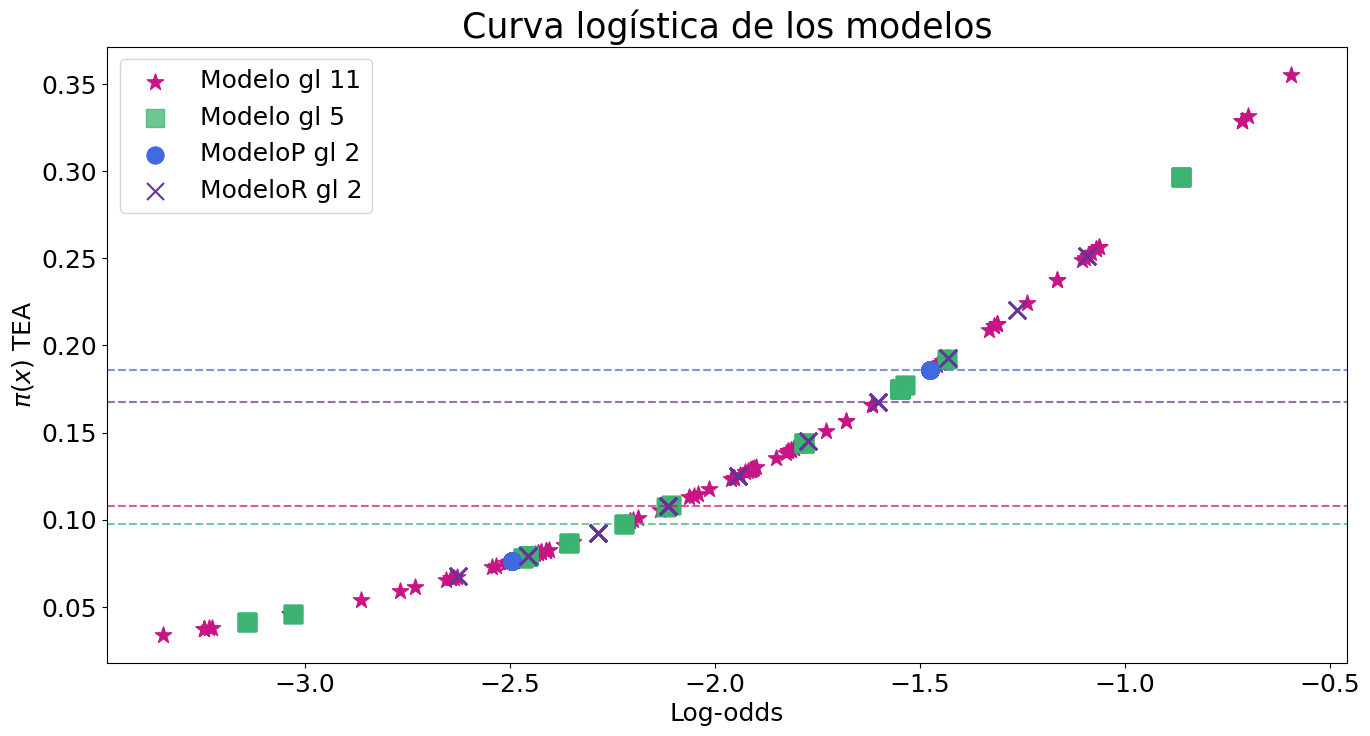

In [21]:
#@title Graficar los modelos
fig, ax = plt.subplots(figsize=(16,8))
ax.set_facecolor('none')

#Umbral de corte
plt.axhline(y=umbral11, color='mediumvioletred', linestyle='--',alpha=0.7)
plt.axhline(y=umbral5, color='mediumseagreen', linestyle='--',alpha=0.7)
plt.axhline(y=umbral2p, color='royalblue', linestyle='--',alpha=0.7)
plt.axhline(y=umbral2r, color='rebeccapurple', linestyle='--',alpha=0.7)

#Predicciones de cada modelo para los valores de todo el conjunto de variables predictores
ax.scatter(z11,pi11,c='mediumvioletred',label='Modelo gl 11', marker='*',s=150)
ax.scatter(z5,pi5,c='mediumseagreen',label='Modelo gl 5',marker='s',alpha=0.75,s=150)
ax.scatter(z2p,pi2p,c='royalblue',label='ModeloP gl 2',marker='o',s=150)
ax.scatter(z2r,pi2r,c='rebeccapurple',label='ModeloR gl 2',marker='x',s=150)

#Datos de la gráfica
ax.set_title("Curva logística de los modelos",fontsize=25)
ax.set_ylabel(r"$\pi(x)$ TEA",fontsize=18)
ax.set_xlabel("Log-odds",fontsize=18);
ax.tick_params(axis='both', labelsize=18)
plt.legend(fontsize=18)
plt.show()